<a href="https://colab.research.google.com/github/rvmvzvn1/jun/blob/main/Hybrid_AI_Fraud_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost shap -q

In [20]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/creditcard.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(df.shape)
print(df["Class"].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"] = scaler.fit_transform(X[["Time"]])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Fraud in train:")
print(y_train.value_counts())
print("Fraud in test:")
print(y_test.value_counts())

X_train: (227845, 30)
X_test: (56962, 30)
Fraud in train:
Class
0    227451
1       394
Name: count, dtype: int64
Fraud in test:
Class
0    56864
1       98
Name: count, dtype: int64


In [ ]:
!pip install xgboost -q

from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.9831461460498662
Precision: 0.5771812080536913
Recall: 0.8775510204081632
F1-score: 0.6963562753036437

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.58      0.88      0.70        98

    accuracy                           1.00     56962
   macro avg       0.79      0.94      0.85     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56801    63]
 [   12    86]]


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_squared_error

In [22]:
X_train_normal = X_train[y_train == 0]

print("Normal transactions for Autoencoder:", X_train_normal.shape)

Normal transactions for Autoencoder: (227451, 30)


In [23]:
input_dim = X_train.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),

    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),

    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,198 (35.93 KB)

 Trainable params: 9,198 (35.93 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.3190 - val_loss: 0.1417
Epoch 2/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1148 - val_loss: 0.0942
Epoch 3/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0832 - val_loss: 0.0723
Epoch 4/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0645 - val_loss: 0.0698
Epoch 5/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0522 - val_loss: 0.0444
Epoch 6/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0440 - val_loss: 0.0408
Epoch 7/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0380 - val_loss: 0.0383
Epoch 8/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0358 - val_loss: 0.0316
Epoch 9/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0331 - val_loss: 0.0340
Epoch 10/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0312 - val_loss: 0.0371
Epoch 11/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0302 - val_loss: 0.0287
Epoch 12/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/ste

In [25]:
X_test_reconstructed = autoencoder.predict(X_test)

reconstruction_errors = np.mean(
    np.square(X_test - X_test_reconstructed),
    axis=1
)

print(reconstruction_errors[:10])

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
263020    0.009828
11378     0.103771
147283    0.159742
219439    0.005780
36939     0.007075
243438    0.018889
259448    0.029546
43800     0.013050
66742     0.003851
66499     0.002006
dtype: float64


In [26]:
threshold = np.percentile(reconstruction_errors, 95)

print("Anomaly threshold:", threshold)

Anomaly threshold: 0.09188874904260452


In [27]:
autoencoder_pred = (reconstruction_errors > threshold).astype(int)

print("Autoencoder Classification Report:")
print(classification_report(y_test, autoencoder_pred))

print("Autoencoder Confusion Matrix:")
print(confusion_matrix(y_test, autoencoder_pred))

Autoencoder Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.86      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.90      0.52     56962
weighted avg       1.00      0.95      0.97     56962

Autoencoder Confusion Matrix:
[[54099  2765]
 [   14    84]]


In [28]:
xgb_scores = model.predict_proba(X_test)[:, 1]

print(xgb_scores[:10])

[1.8021245e-04 4.5399731e-05 1.6911244e-03 5.4900633e-05 3.5210539e-02
 1.4418850e-04 6.7492860e-05 8.1021622e-05 8.6583785e-04 3.8924266e-04]


In [29]:
reconstruction_norm = (
    reconstruction_errors - reconstruction_errors.min()
) / (
    reconstruction_errors.max() - reconstruction_errors.min()
)

print(reconstruction_norm[:10])

263020    0.000093
11378     0.001041
147283    0.001606
219439    0.000052
36939     0.000065
243438    0.000185
259448    0.000292
43800     0.000126
66742     0.000033
66499     0.000014
dtype: float64


In [30]:
final_risk_score = (
    0.7 * xgb_scores +
    0.3 * reconstruction_norm
)

print(final_risk_score[:10])

263020    0.000154
11378     0.000344
147283    0.001666
219439    0.000054
36939     0.024667
243438    0.000156
259448    0.000135
43800     0.000094
66742     0.000616
66499     0.000277
dtype: float64


In [31]:
hybrid_pred = (final_risk_score > 0.5).astype(int)

In [32]:
print("Hybrid Fraud System Report:")
print(classification_report(y_test, hybrid_pred))

print("Hybrid Confusion Matrix:")
print(confusion_matrix(y_test, hybrid_pred))

Hybrid Fraud System Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.87      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

Hybrid Confusion Matrix:
[[56828    36]
 [   13    85]]


In [33]:
!pip install shap -q

In [34]:
import shap

In [35]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

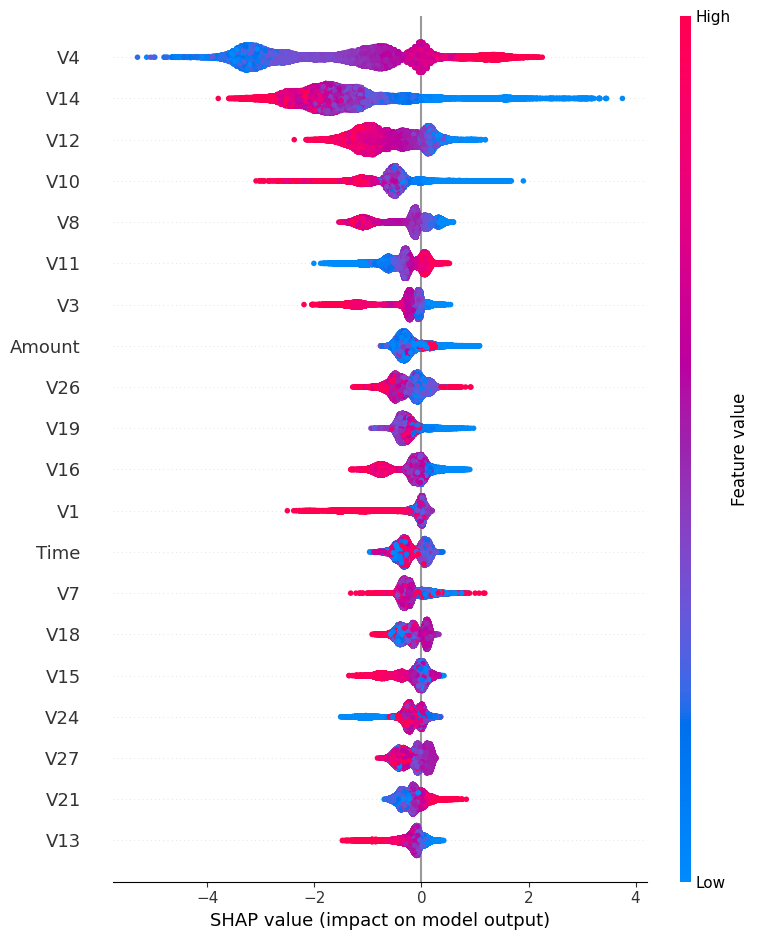

In [36]:
shap.summary_plot(shap_values, X_test)

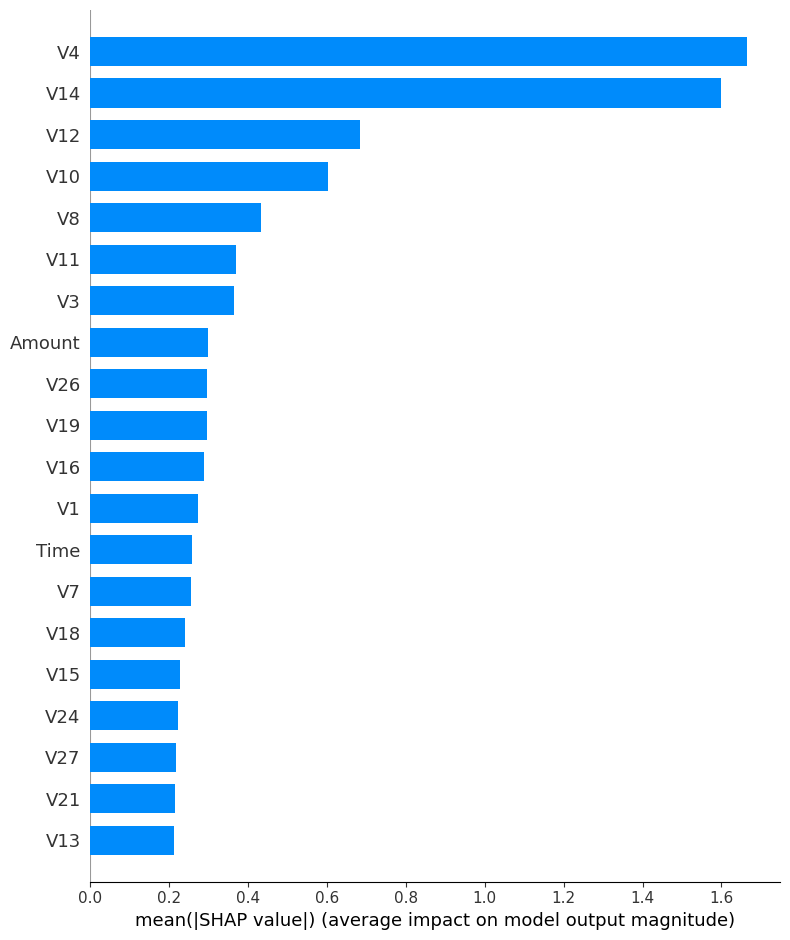

In [37]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [38]:
suspicious_index = np.argmax(final_risk_score)

print("Suspicious index:", suspicious_index)
print("Hybrid risk score:", final_risk_score[suspicious_index])
print("Actual class:", y_test.iloc[suspicious_index])

Suspicious index: 19638
Hybrid risk score: 0.025522835099833725
Actual class: 1


In [39]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[suspicious_index],
    X_test.iloc[suspicious_index]
)

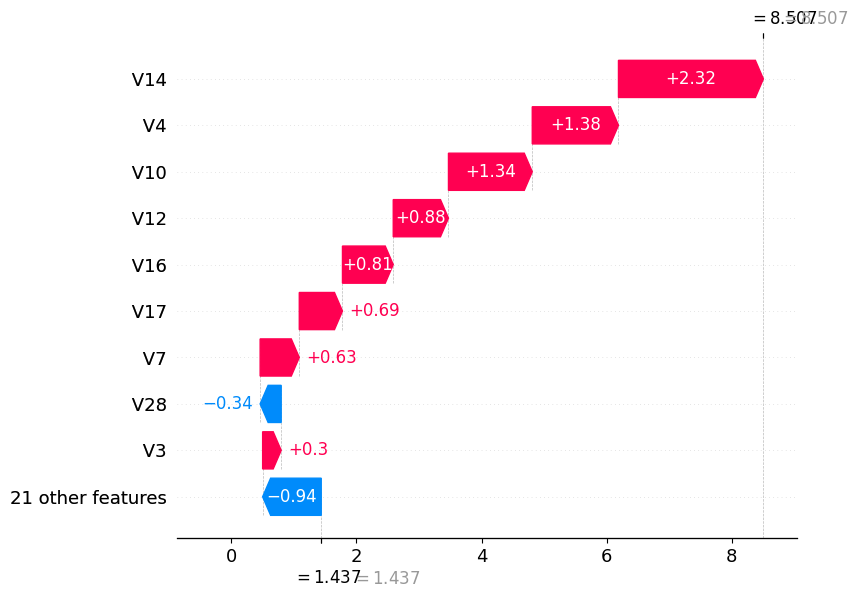

In [40]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[suspicious_index],
    X_test.iloc[suspicious_index]
)